## Coursework 2 Group (text)

Group number: 29

Student names and k-numbers:
1. Kishan Bangsi Magar - K2545729
2. Pradeep Appasaheb Nayak - K2520606
3. Shweta Patankar - K2557766
4. Daniel Rolon Rodriguez - K2552225

# Load modules (code)

In [ ]:
# Install dependencies
!pip install medmnist

#Deep learning framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

#Data handling
import numpy as np
import random
import math

# Dataset
import medmnist
from medmnist import INFO

# Pre-processing / Utilities
from sklearn.model_selection import train_test_split

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Load data

In [ ]:
#Dataset selection
data_flag = "organsmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

#Dataset loading
train_dataset = DataClass(split="train", download=True, size=224)
val_dataset   = DataClass(split="val", download=True, size=224)
test_dataset  = DataClass(split="test", download=True, size=224)

#NumPy formatting
X_train, y_train = train_dataset.imgs, train_dataset.labels
X_val, y_val     = val_dataset.imgs, val_dataset.labels
X_test, y_test   = test_dataset.imgs, test_dataset.labels


# Initial Visualisation

##Basic observations

In [ ]:
#Dataset shape checks
print("Train shape:")
print("X:", X_train.shape)
print("y:", y_train.shape)

print("\nValidation shape:")
print("X:", X_val.shape)
print("y:", y_val.shape)

print("\nTest shape:")
print("X:", X_test.shape)
print("y:", y_test.shape)

#Label visualisation
print("\nNumber of classes:", len(info["label"]))
print("Class labels:")
for idx, name in info["label"].items():
    print(f"{idx}: {name}")

Train shape:
X: (13932, 224, 224)
y: (13932, 1)

Validation shape:
X: (2452, 224, 224)
y: (2452, 1)

Test shape:
X: (8827, 224, 224)
y: (8827, 1)

Number of classes: 11
Class labels:
0: bladder
1: femur-left
2: femur-right
3: heart
4: kidney-left
5: kidney-right
6: liver
7: lung-left
8: lung-right
9: pancreas
10: spleen


##Class balance observation

### Setup

In [ ]:
class_names = list(info["label"].values())
num_classes = len(class_names)

def get_class_counts(labels, num_classes):
    counts = np.zeros(num_classes)

    # labels often come as shape (N, 1)
    labels = np.squeeze(labels)

    for l in labels:
        counts[int(l)] += 1

    return counts

def plot_histogram(counts, title):
    plt.figure(figsize=(10,5))
    plt.bar(class_names, counts)
    plt.xticks(rotation=45, ha='right')
    plt.title(title)
    plt.ylabel("Number of samples")
    plt.tight_layout()
    print("\n")
    plt.show()

def plot_pie(counts, title):
    plt.figure(figsize=(8,8))
    colours = plt.cm.tab20(np.linspace(0, 1, len(counts)))
    plt.pie(counts, labels=class_names, autopct='%1.1f%%', colors=colours)
    plt.title(title)
    print("\n")
    plt.show()

### Train split

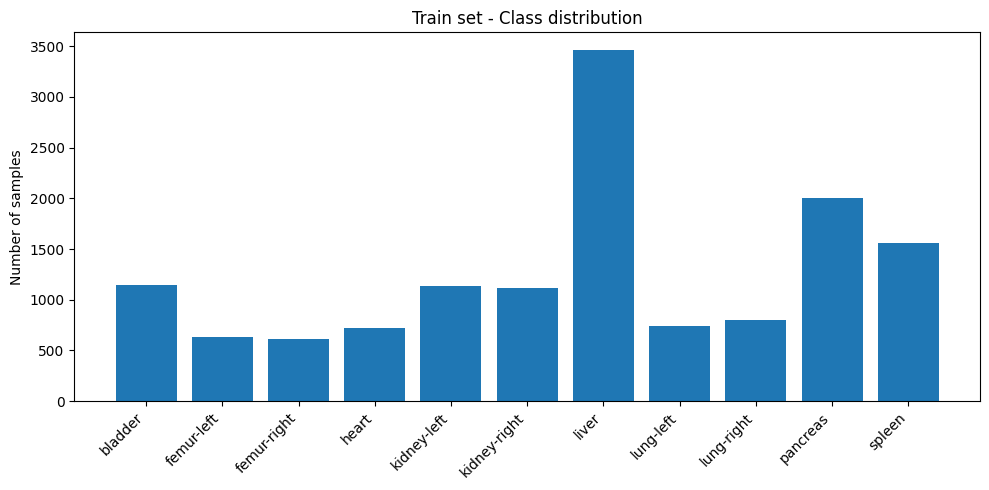

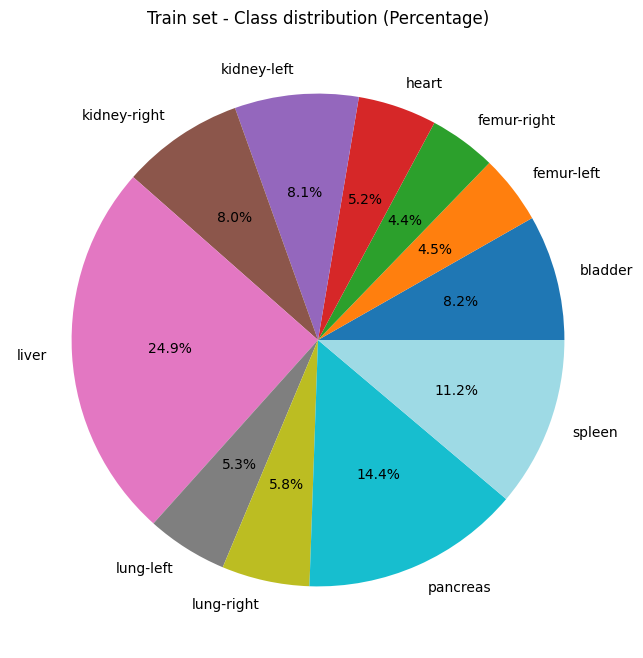

In [ ]:
train_counts = get_class_counts(y_train, num_classes)
plot_histogram(train_counts, "Train set - Class distribution")
plot_pie(train_counts, "Train set - Class distribution (Percentage)")

### Validation split


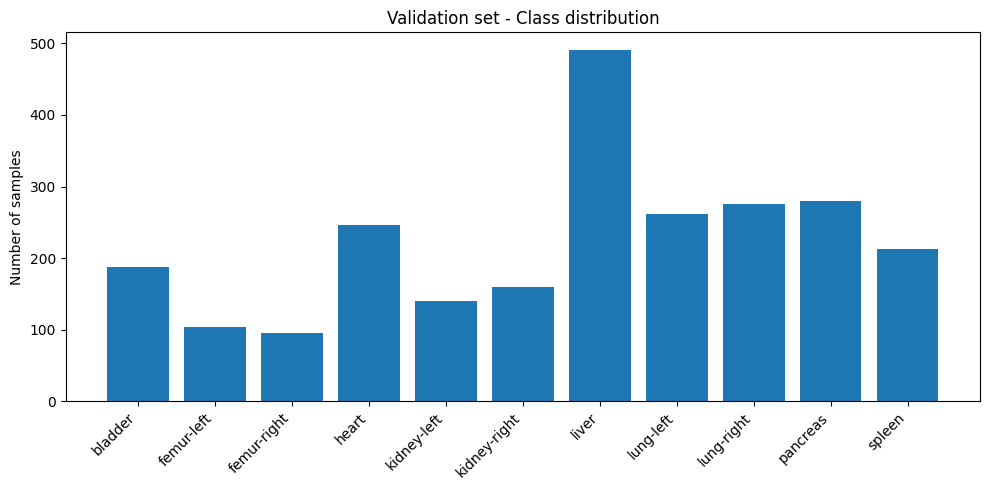

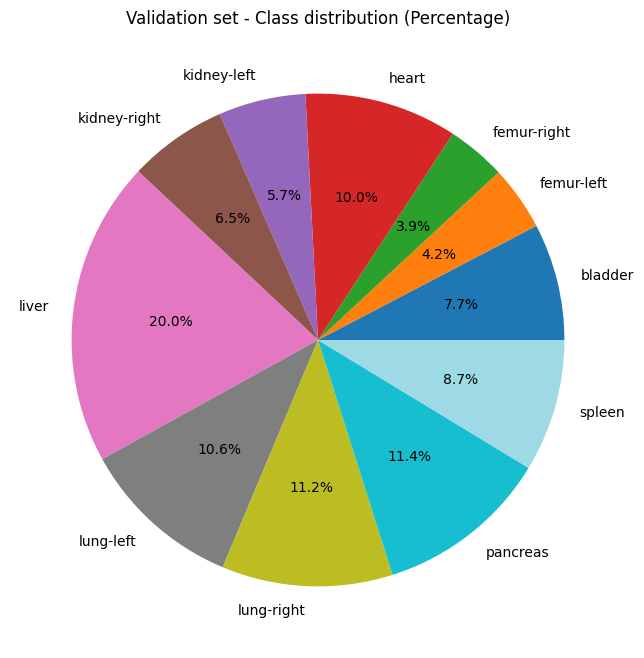

In [ ]:
val_counts   = get_class_counts(y_val, num_classes)
plot_histogram(val_counts, "Validation set - Class distribution")
plot_pie(val_counts, "Validation set - Class distribution (Percentage)")


### Test split

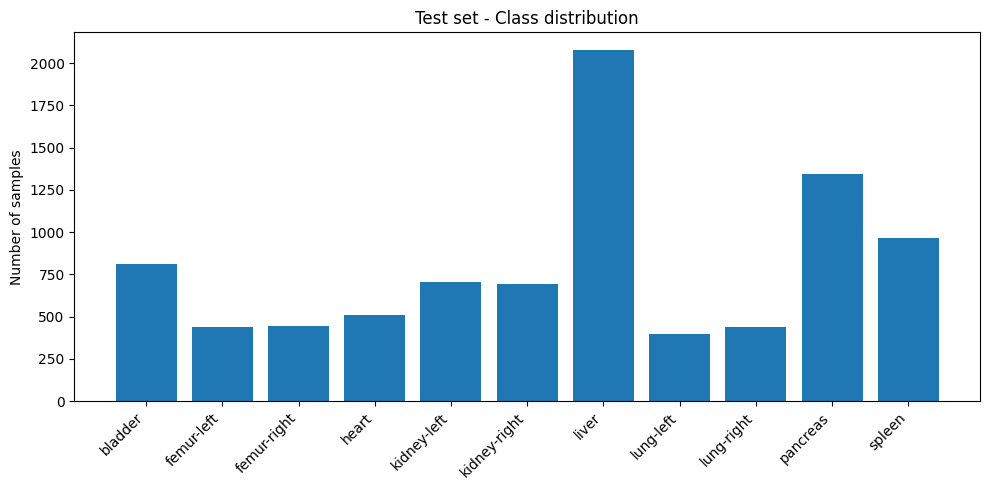

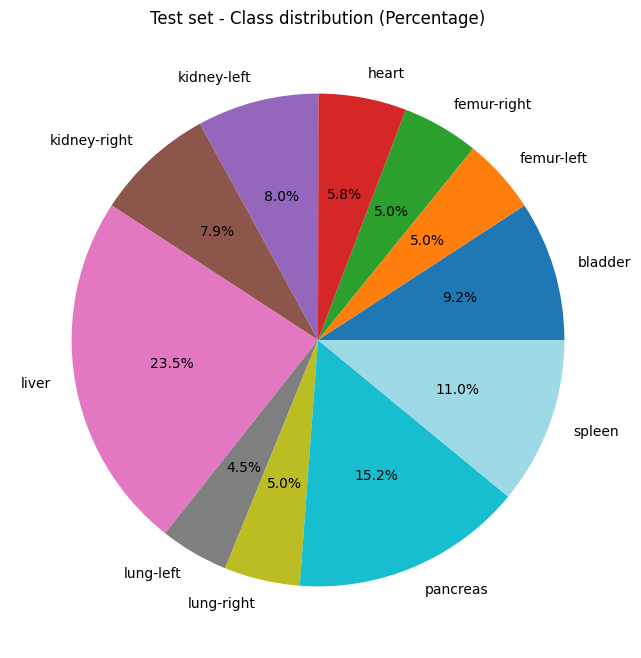

In [ ]:
test_counts  = get_class_counts(y_test, num_classes)
plot_histogram(test_counts, "Test set - Class distribution")
plot_pie(test_counts, "Test set - Class distribution (Percentage)")

### Split comparison

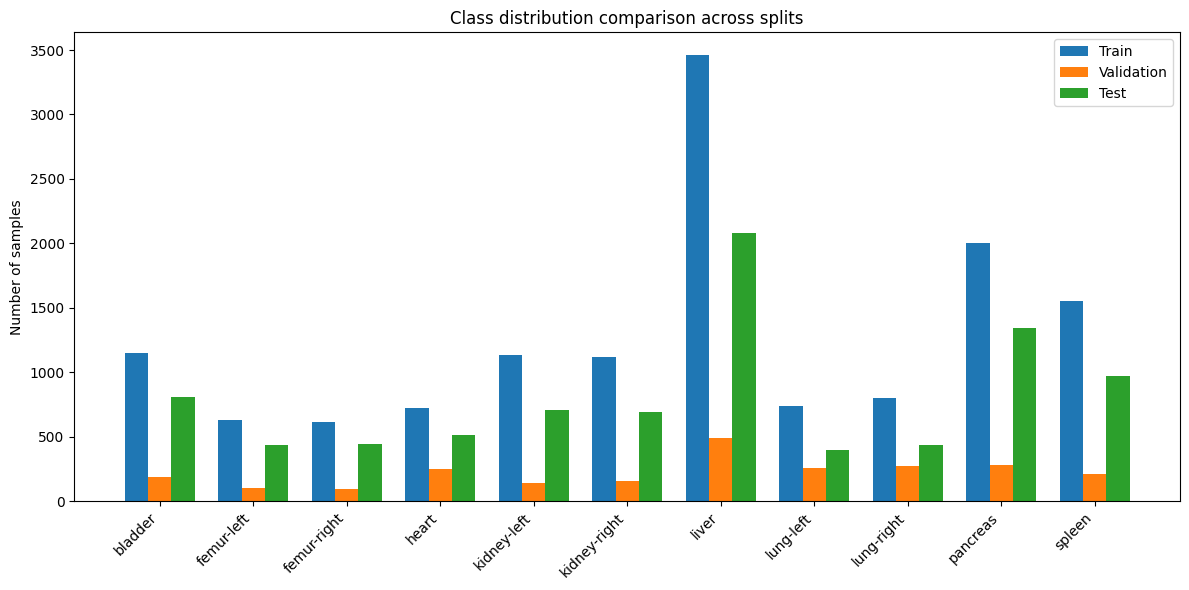

In [ ]:
x = np.arange(num_classes)
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(x - width, train_counts, width, label='Train')
plt.bar(x, val_counts, width, label='Validation')
plt.bar(x + width, test_counts, width, label='Test')

plt.xticks(x, class_names, rotation=45, ha='right')
plt.title("Class distribution comparison across splits")
plt.ylabel("Number of samples")
plt.legend()
plt.tight_layout()
plt.show()

## Sample visualisation

### Setup

In [ ]:
def show_images(images, labels, title, class_names, n=None):
    if n is None:
        n = len(images)

    cols = 3
    rows = math.ceil(n / cols)

    plt.figure(figsize=(6, 2 * rows))

    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(class_names[int(labels[i])])
        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def show_one_per_class(X, y, title):
    seen = {}
    images = []
    labels = []

    y = np.squeeze(y)

    for img, label in zip(X, y):
        label = int(label)

        if label not in seen:
            seen[label] = True
            images.append(img)
            labels.append(label)

        if len(seen) == len(class_names):
            break

    show_images(images, labels, title, class_names, n=len(class_names))

def show_samples_per_class(X, y, class_names, samples_per_class=5):
    y = np.squeeze(y)

    num_classes = len(class_names)

    for cls in range(num_classes):

        # get all images of this class
        idx = np.where(y == cls)[0]

        # handle edge case
        if len(idx) == 0:
            continue

        # randomly sample from this class
        chosen = np.random.choice(idx,
                                   size=min(samples_per_class, len(idx)),
                                   replace=False)

        images = X[chosen]
        labels = y[chosen]

        # plot grid
        cols = samples_per_class
        rows = 1

        plt.figure(figsize=(2 * cols, 2))

        for i in range(len(images)):
            plt.subplot(rows, cols, i + 1)
            plt.imshow(images[i], cmap='gray')
            plt.title(class_names[int(labels[i])], fontsize=8)
            plt.axis('off')

        plt.suptitle(f"Class {cls}: {class_names[cls]}", fontsize=12)
        plt.tight_layout()
        plt.show()

### Random samples

/tmp/ipykernel_7711/1415176666.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(labels[i])])


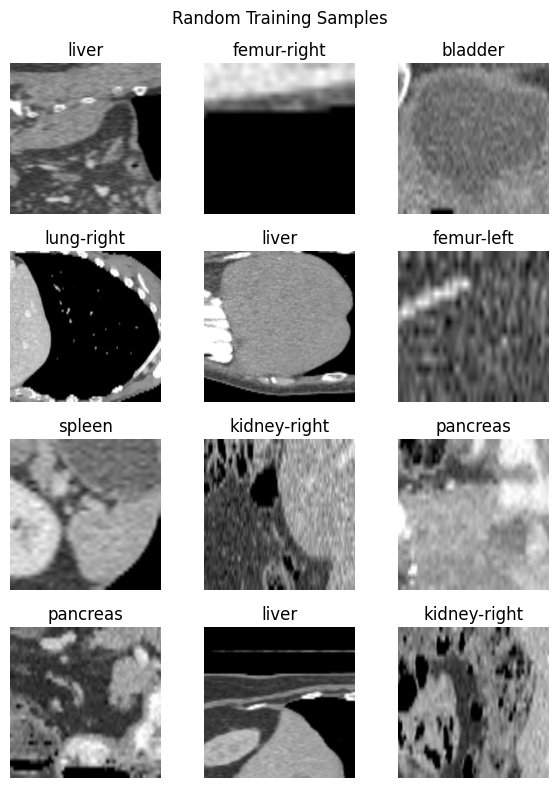

In [ ]:
idx = np.random.choice(len(X_train), 12, replace=False)

show_images(
    X_train[idx],
    y_train[idx],
    "Random Training Samples",
    class_names
)

### One per class

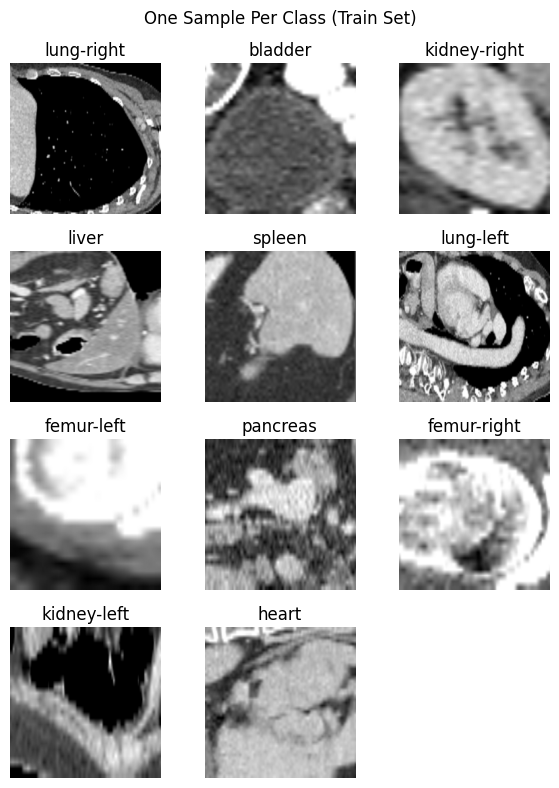

In [ ]:
show_one_per_class(X_train, y_train, "One Sample Per Class (Train Set)")

### Random per class

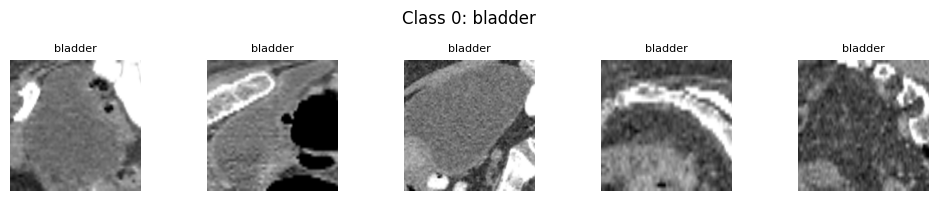

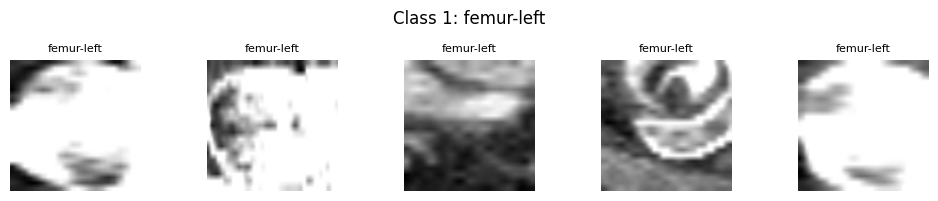

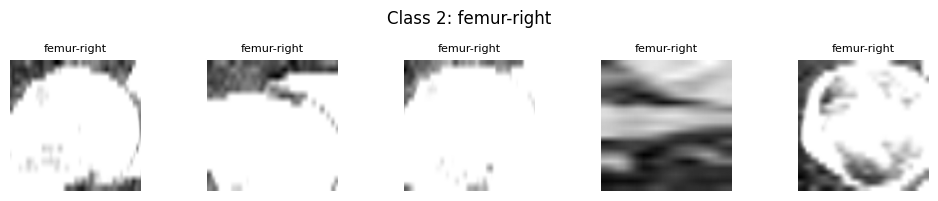

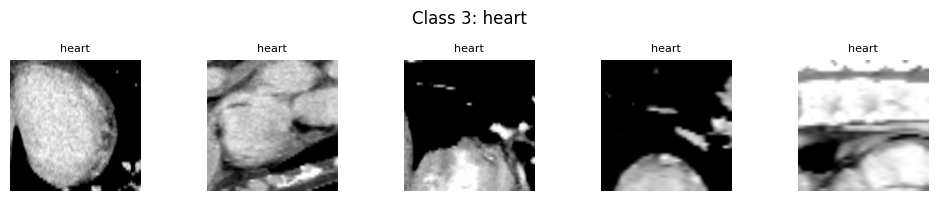

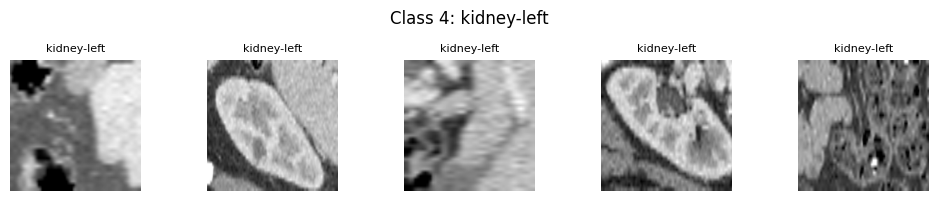

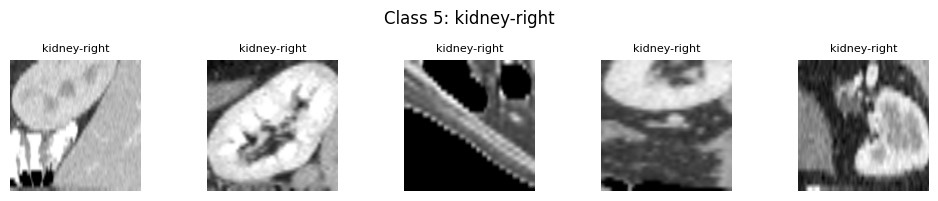

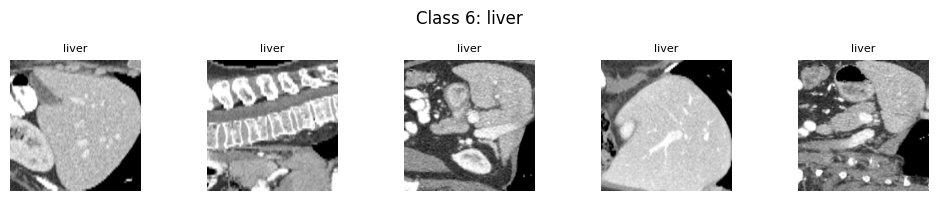

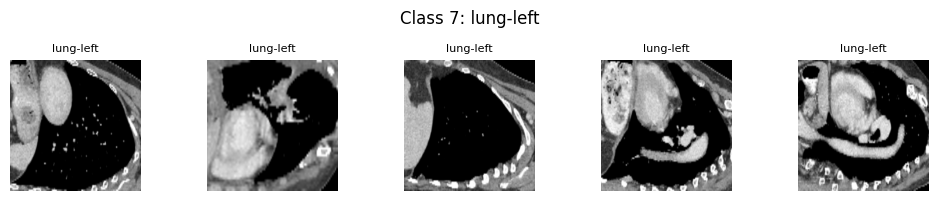

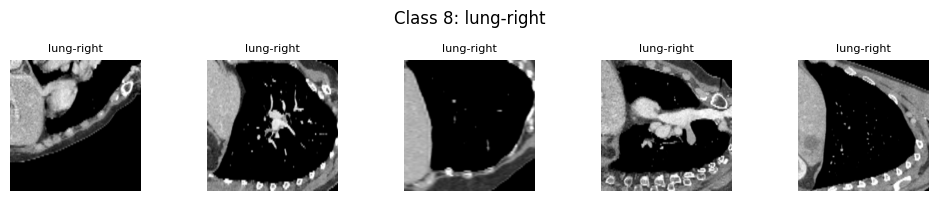

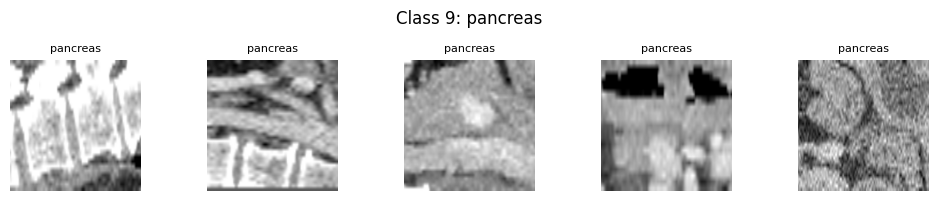

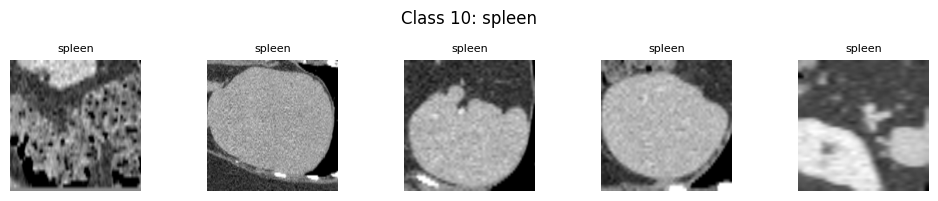

In [ ]:
show_samples_per_class(
    X_train,
    y_train,
    class_names,
    samples_per_class=5
)

# Q1

In [ ]:
# add code for Q1

## Q2

In [ ]:
# add code for Q2

In [ ]:
# add discussion for Q2

# Q3

In [ ]:
# add code for Q3

## Q4

In [ ]:
# add code for Q4

In [ ]:
# add discussion for Q4

## Q5

In [ ]:
# add code for Q5

In [ ]:
# add discussion for Q5

## Q6

In [ ]:
# add code for Q6

In [ ]:
# add discussion for Q6

## Q7

In [ ]:
# add code for Q7

In [ ]:
# add discussion for Q7

# References (text)

List any references you may have used in your document before, using one of the established referencing system (e.g. IEEE, Harvard, etc).